# STATS 426 – Music Hit Prediction: Final Model Notebook
  
**Primary metric:** AUPRC (Area Under the Precision-Recall Curve) — optimal for
heavily imbalanced binary classification.  
Secondary metrics: ROC-AUC, F1 (at val-tuned threshold), Precision, Recall.

### Models compared
| # | Model | Notes |
|---|-------|-------|
| 1 | Logistic Regression | Interpretable baseline |
| 2 | XGBoost | Strong gradient-boosted baseline |
| 3 | TabNet (CV-tuned) | Attentive tabular DL |
| 4 | Wide & Deep NN + Genre Embeddings | End-to-end deep model |

## 0  Installs & Imports

In [48]:

!pip install pytorch-tabnet -q

In [49]:
# Standard libraries
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    average_precision_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

# XGBoost
from xgboost import XGBClassifier

# TabNet
from pytorch_tabnet.tab_model import TabNetClassifier

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 1  Data Loading & Cleaning
Ethan's pipeline: load → aggregate chart data → define hit label → select audio features → clean.

In [50]:
from google.colab import files
uploaded = files.upload()

In [51]:
#os.rename("audio_features (1).csv", "audio_features.csv")
#os.rename("leader_board (1).csv",   "leader_board.csv")

audio = pd.read_csv("audio_features.csv")
lb    = pd.read_csv("leader_board.csv")

print(audio.head())
print(lb.head())

   index                                             SongID  \
0      0     -twistin'-White Silver SandsBill Black's Combo   
1      1  ¿Dònde Està Santa Claus? (Where Is Santa Claus...   
2      2             ......And Roses And RosesAndy Williams   
3      3           ...And Then There Were DrumsSandy Nelson   
4      4                ...Baby One More TimeBritney Spears   

            Performer                                              Song  \
0  Bill Black's Combo                      -twistin'-White Silver Sands   
1          Augie Rios  ¿Dònde Està Santa Claus? (Where Is Santa Claus?)   
2       Andy Williams                         ......And Roses And Roses   
3        Sandy Nelson                      ...And Then There Were Drums   
4      Britney Spears                             ...Baby One More Time   

                                       spotify_genre        spotify_track_id  \
0                                                 []                     NaN   
1         

In [52]:
# Aggregate weekly chart data to song level
lb["WeekID"] = pd.to_datetime(lb["WeekID"], format="%m/%d/%Y", errors="coerce")

lb_song = (
    lb.groupby("SongID", as_index=False)
      .agg(
          first_week      = ("WeekID",         "min"),
          last_week       = ("WeekID",         "max"),
          peak_position   = ("Peak Position",  "min"),   # lower is better
          weeks_on_chart  = ("Weeks on Chart", "max"),
      )
      .assign(
          # HIT DEFINITION: Top-10 peak AND ≥ 15 weeks on chart
          hit=lambda d: (
              (d.peak_position <= 10) & (d.weeks_on_chart >= 15)
          ).astype(int)
      )
)

print(f"Songs in leaderboard: {len(lb_song):,}")
print(f"Hit rate: {lb_song['hit'].mean()*100:.2f}%")

Songs in leaderboard: 29,389
Hit rate: 13.05%


In [53]:
#  Select and clean audio features
AUDIO_COLS = [
    "SongID", "spotify_genre", "spotify_track_duration_ms",
    "spotify_track_explicit", "danceability", "energy", "key",
    "loudness", "mode", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence", "tempo", "time_signature"
]
audio = audio[AUDIO_COLS].dropna()

# bool to int
audio["spotify_track_explicit"] = audio["spotify_track_explicit"].astype(int)

print(f"Audio rows after cleaning: {len(audio):,}")

Audio rows after cleaning: 24,186


## 2  Genre Encoding
Build a vocabulary, encode each song's genre list as integer IDs, and pre-compute
**frozen** mean-pooled embeddings (used by tree-based models and TabNet as numeric
features).  The neural network will **re-learn** its own genre embeddings end-to-end.

In [54]:
# Normalise genre strings
def normalize_genres(x):
    if x == "[]" or pd.isna(x):
        return ["unknown"]
    try:
        return ast.literal_eval(x)
    except Exception:
        return ["unknown"]

audio["spotify_genre"] = audio["spotify_genre"].apply(normalize_genres)

# Build vocabulary
PAD, UNK   = "<PAD>", "<UNK>"
all_genres = sorted({g for genres in audio["spotify_genre"] for g in genres})

genre2idx = {PAD: 0, UNK: 1}
for g in all_genres:
    if g not in genre2idx:
        genre2idx[g] = len(genre2idx)

vocab_size = len(genre2idx)
MAX_GENRES = 5

print(f"Genre vocab size: {vocab_size:,}")

# Encode genres as padded integer sequences
def encode_genres(genres):
    ids = [genre2idx.get(g, genre2idx[UNK]) for g in genres][:MAX_GENRES]
    ids += [genre2idx[PAD]] * (MAX_GENRES - len(ids))
    return ids

audio["spotify_genre_ids"] = audio["spotify_genre"].apply(encode_genres)

Genre vocab size: 1,045


In [55]:
#Pre-compute FROZEN mean-pooled genre embeddings (for non-NN models)
EMBED_DIM = 16

class GenreEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

    def forward(self, genre_ids):
        e    = self.emb(genre_ids)                                     # (N, MAX_GENRES, D)
        mask = (genre_ids != self.pad_idx).unsqueeze(-1).float()      # (N, MAX_GENRES, 1)
        e    = e * mask
        denom  = mask.sum(dim=1).clamp(min=1.0)                       # (N, 1)
        return e.sum(dim=1) / denom                                    # (N, D)

genre_encoder = GenreEncoder(vocab_size, EMBED_DIM)

genre_ids_tensor = torch.tensor(
    pd.DataFrame(audio["spotify_genre_ids"].to_list()).values,
    dtype=torch.long
)

with torch.no_grad():
    genre_vecs = genre_encoder(genre_ids_tensor).numpy()

genre_emb_df = pd.DataFrame(
    genre_vecs,
    columns=[f"genre_emb_{i+1}" for i in range(EMBED_DIM)],
    index=audio.index
)

audio = pd.concat([audio, genre_emb_df], axis=1)
print("Genre embeddings attached. audio.shape:", audio.shape)

Genre embeddings attached. audio.shape: (24186, 33)


## 3  Merge & Feature Engineering

In [56]:
#  Merge audio + chart data
df = audio.merge(lb_song, on="SongID", how="inner")
df = df.sort_values("first_week").reset_index(drop=True)

print(f"Merged dataset: {df.shape}")
print(f"Hit rate: {df['hit'].mean()*100:.2f}%")
print(f"Date range: {df['first_week'].min().date()} → {df['last_week'].max().date()}")

Merged dataset: (24185, 38)
Hit rate: 14.30%
Date range: 1958-08-02 → 2021-05-29


In [57]:
#Feature engineering
# Interaction features (Ethan's originals + extras)
df["energy_x_dance"]    = df["energy"]      * df["danceability"]
df["valence_x_energy"]  = df["valence"]     * df["energy"]
df["tempo_x_energy"]    = df["tempo"]       * df["energy"]
df["loudness_abs"]      = df["loudness"].abs()

# Additional meaningful interactions
df["acoustic_x_vocal"]  = df["acousticness"] * df["speechiness"]   # acoustic vocal style
df["dance_x_valence"]   = df["danceability"]  * df["valence"]       # upbeat danceable
df["energy_sq"]         = df["energy"] ** 2                         # non-linear energy
df["tempo_norm"]        = df["tempo"] / 200.0                       # normalise BPM

print("Feature engineering done. New columns added.")
df.isnull().sum()[df.isnull().sum() > 0]

Feature engineering done. New columns added.


,0


## 4  Train / Val / Test Split (70 / 15 / 15, stratified)
> **Note:** `first_week`, `last_week`, `peak_position`, and `weeks_on_chart` are ALL
> dropped — they would constitute label leakage (they're derived from the same chart
> data used to define the hit label).

In [58]:
# Columns to exclude from features
LEAK_COLS = [
    "SongID", "hit",
    "peak_position", "weeks_on_chart",   # leakage — used to define 'hit'
    "first_week", "last_week",           # date metadata, not audio features
    "spotify_genre", "spotify_genre_ids" # non-numeric, raw genre data
]

# Feature matrix for tree-based models & TabNet (numeric only)
X_tab = df.drop(columns=LEAK_COLS).select_dtypes(include=[np.number])
y     = df["hit"]

print(f"Feature matrix shape: {X_tab.shape}")
print(f"Features: {list(X_tab.columns)}")

#Preserve genre_ids separately for the end-to-end NN
genre_ids_all = np.stack(df["spotify_genre_ids"].values)  # (N, MAX_GENRES)

#  70 / 30 first split
(X_train, X_temp,
 g_train, g_temp,
 y_train, y_temp) = train_test_split(
    X_tab.values, genre_ids_all, y.values,
    test_size=0.30, random_state=426, stratify=y
)

# 30-->15 val / 15 test
(X_val, X_test,
 g_val, g_test,
 y_val, y_test) = train_test_split(
    X_temp, g_temp, y_temp,
    test_size=0.50, random_state=426, stratify=y_temp
)

for split, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{split}: {len(yy):,} samples | hit rate: {yy.mean()*100:.2f}%")

Feature matrix shape: (24185, 38)
Features: ['spotify_track_duration_ms', 'spotify_track_explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'genre_emb_1', 'genre_emb_2', 'genre_emb_3', 'genre_emb_4', 'genre_emb_5', 'genre_emb_6', 'genre_emb_7', 'genre_emb_8', 'genre_emb_9', 'genre_emb_10', 'genre_emb_11', 'genre_emb_12', 'genre_emb_13', 'genre_emb_14', 'genre_emb_15', 'genre_emb_16', 'energy_x_dance', 'valence_x_energy', 'tempo_x_energy', 'loudness_abs', 'acoustic_x_vocal', 'dance_x_valence', 'energy_sq', 'tempo_norm']
Train: 16,929 samples | hit rate: 14.30%
Val: 3,628 samples | hit rate: 14.31%
Test: 3,628 samples | hit rate: 14.31%


## 5  Preprocessing
**Critical fix from Daniel's notebook:** `scaler.fit_transform` was called on the
validation and test sets — this leaks test distribution information.  
We `fit` only on training data and `transform` all others.

In [59]:
# tandardScaler fit on TRAIN only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)    # ← FIX: was fit_transform in Daniel's nb
X_test_s  = scaler.transform(X_test)  # ← FIX: was fit_transform in Daniel's nb

input_dim = X_train_s.shape[1]
print(f"Input dimension: {input_dim}")

Input dimension: 38


## 6  Evaluation Utilities
A unified `evaluate()` function used by every model:
- Finds the **F1-optimal threshold** on the *validation* set  
- Reports AUPRC (primary), ROC-AUC, F1, Precision, Recall, Accuracy on the *test* set

In [60]:
def find_best_threshold(y_true, y_prob):
    """Return the probability threshold that maximises F1 on a validation set."""
    prec, rec, thresh = precision_recall_curve(y_true, y_prob)
    f1s = 2 * prec * rec / (prec + rec + 1e-8)
    best_idx = np.argmax(f1s[:-1])   # last element has no corresponding threshold
    return float(thresh[best_idx])


def evaluate(model_name, y_val, val_probs, y_test, test_probs, show_cm=True):
    """
    Param

    y_val, val_probs   : validation labels + predicted probabilities (for threshold tuning)
    y_test, test_probs : test labels + predicted probabilities (for final metrics)
    """
    # threshold tuned on val set trff
    thresh = find_best_threshold(y_val, val_probs)

    #  test set metrics
    preds  = (test_probs >= thresh).astype(int)

    auprc  = average_precision_score(y_test, test_probs)
    roc    = roc_auc_score(y_test, test_probs)
    f1     = f1_score(y_test, preds)
    prec   = precision_score(y_test, preds, zero_division=0)
    rec    = recall_score(y_test, preds, zero_division=0)
    acc    = accuracy_score(y_test, preds)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  AUPRC  (primary) : {auprc:.4f}")
    print(f"  ROC-AUC          : {roc:.4f}")
    print(f"  F1 (thresh={thresh:.3f}): {f1:.4f}")
    print(f"  Precision        : {prec:.4f}")
    print(f"  Recall           : {rec:.4f}")
    print(f"  Accuracy         : {acc:.4f}")
    print(f"{'='*50}")

    if show_cm:
        cm = confusion_matrix(y_test, preds)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Confusion matrix
        ConfusionMatrixDisplay(cm, display_labels=["Non-Hit","Hit"]).plot(ax=axes[0], colorbar=False)
        axes[0].set_title(f"{model_name} – Confusion Matrix")

        # Precision-Recall curve
        prec_c, rec_c, _ = precision_recall_curve(y_test, test_probs)
        baseline = y_test.mean()
        axes[1].plot(rec_c, prec_c, lw=2, label=f"AUPRC = {auprc:.3f}")
        axes[1].axhline(baseline, linestyle="--", color="gray", label=f"Random = {baseline:.3f}")
        axes[1].set_xlabel("Recall")
        axes[1].set_ylabel("Precision")
        axes[1].set_title(f"{model_name} – Precision-Recall Curve")
        axes[1].legend()
        plt.tight_layout()
        plt.show()

    return dict(model=model_name, AUPRC=auprc, ROC_AUC=roc, F1=f1,
                Precision=prec, Recall=rec, Accuracy=acc, Threshold=thresh)

results_summary = []   # collect results from every model

## 7  Model 1: Logistic Regression (Baseline)


  Logistic Regression
  AUPRC  (primary) : 0.2398
  ROC-AUC          : 0.6739
  F1 (thresh=0.477): 0.3228
  Precision        : 0.2124
  Recall           : 0.6724
  Accuracy         : 0.5965


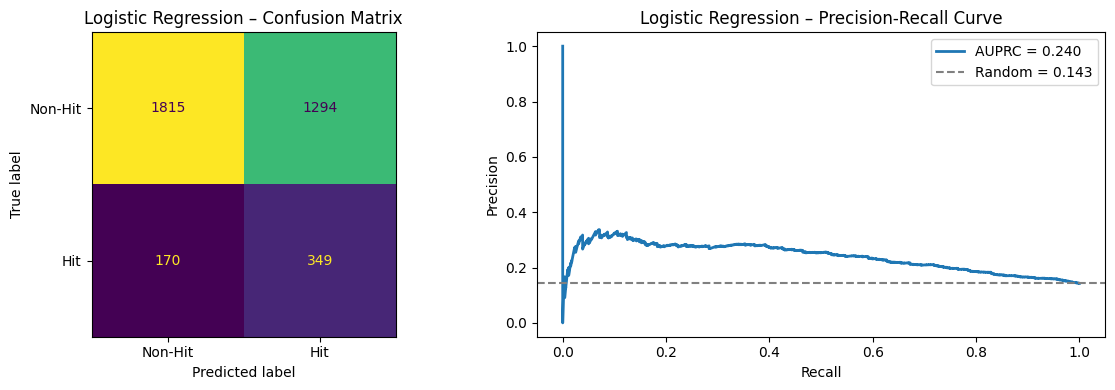

In [61]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=10_000,
    solver="lbfgs",
    C=0.1,             # mild regularisation WEEWOOOWEOO
    random_state=426
)
lr_model.fit(X_train_s, y_train)

val_probs_lr  = lr_model.predict_proba(X_val_s)[:, 1]
test_probs_lr = lr_model.predict_proba(X_test_s)[:, 1]

res = evaluate("Logistic Regression", y_val, val_probs_lr, y_test, test_probs_lr)
results_summary.append(res)

## 8  Model 2: XGBoost
`scale_pos_weight` corrects class imbalance; `eval_metric='aucpr'` aligns training
with our primary metric (AUPRC). Early stopping on the validation set prevents
overfitting without needing to pre-specify n_estimators.

scale_pos_weight = 5.99  (neg/pos = 14508/2421)
Best iteration: 292

  XGBoost
  AUPRC  (primary) : 0.3166
  ROC-AUC          : 0.7197
  F1 (thresh=0.488): 0.3735
  Precision        : 0.2738
  Recall           : 0.5877
  Accuracy         : 0.7180


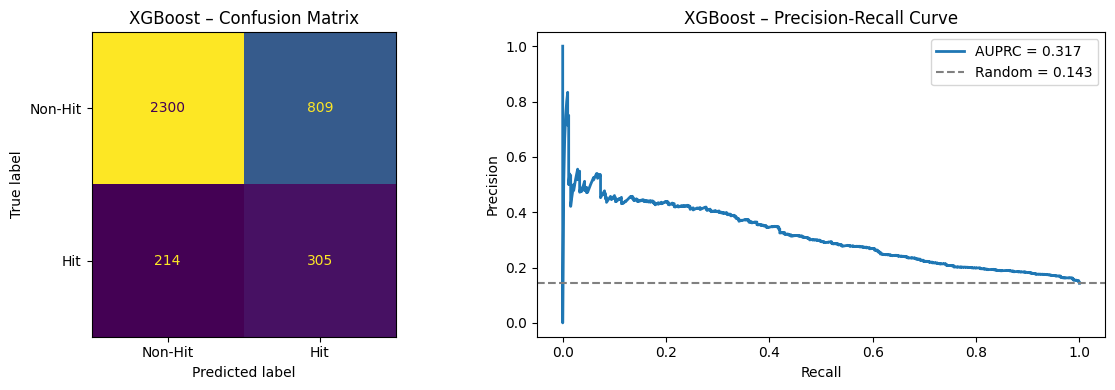

In [62]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.2f}  (neg/pos = {neg}/{pos})")

xgb_model = XGBClassifier(
    n_estimators        = 1000,
    learning_rate       = 0.05,
    max_depth           = 5,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    min_child_weight    = 3,
    scale_pos_weight    = spw,
    eval_metric         = "aucpr",   # optimise AUPRC (our primary metric)
    early_stopping_rounds = 30,
    random_state        = 426,
    use_label_encoder   = False
)

xgb_model.fit(
    X_train_s, y_train,
    eval_set    = [(X_val_s, y_val)],
    verbose     = False
)

print(f"Best iteration: {xgb_model.best_iteration}")

val_probs_xgb  = xgb_model.predict_proba(X_val_s)[:, 1]
test_probs_xgb = xgb_model.predict_proba(X_test_s)[:, 1]

res = evaluate("XGBoost", y_val, val_probs_xgb, y_test, test_probs_xgb)
results_summary.append(res)

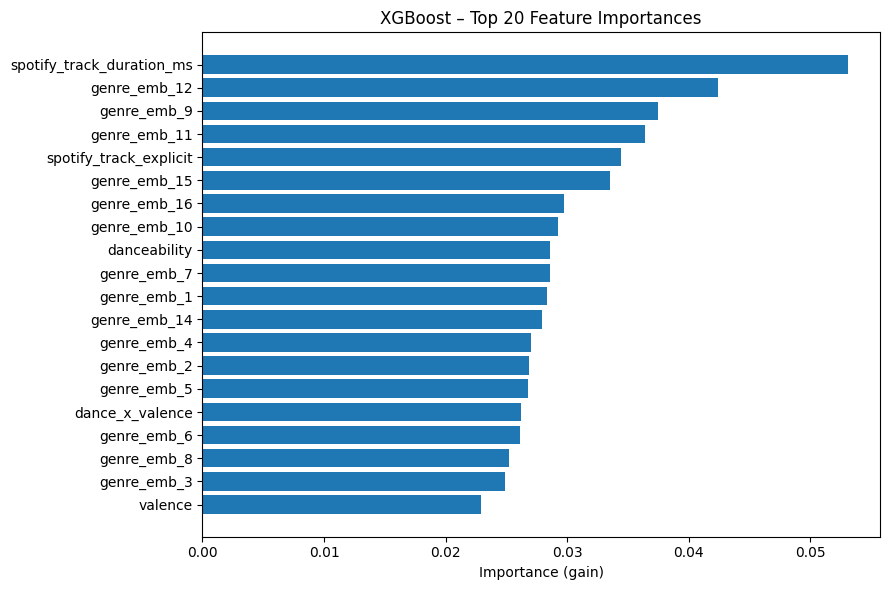

In [63]:
# XGBoost feature importance
feat_names = X_tab.columns.tolist()
importances = xgb_model.feature_importances_

top_n = 20
sorted_idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(9, 6))
plt.barh(
    [feat_names[i] for i in sorted_idx[::-1]],
    importances[sorted_idx[::-1]]
)
plt.xlabel("Importance (gain)")
plt.title(f"XGBoost – Top {top_n} Feature Importances")
plt.tight_layout()
plt.show()

## 9  Model 3: TabNet (with Cross-Validation Hyperparameter Search)
From the TabNet notebook:  
1. Grid-search a small set of configurations using 5-fold stratified CV on the training set.  
2. Retrain the best config on all training data (90%) with a small held-out val set (10%) for early stopping.  
3. Evaluate on the untouched test set.

In [64]:
# TabNet configs to grid-search
TABNET_CONFIGS = [
    dict(n_d=32, n_a=32, n_steps=5, gamma=1.5, lambda_sparse=1e-3, lr=1e-3),
    dict(n_d=32, n_a=32, n_steps=6, gamma=1.5, lambda_sparse=1e-3, lr=1e-3),
    dict(n_d=32, n_a=32, n_steps=5, gamma=1.8, lambda_sparse=1e-2, lr=1e-3),
    dict(n_d=32, n_a=32, n_steps=5, gamma=1.5, lambda_sparse=0,    lr=1e-3),
    dict(n_d=64, n_a=64, n_steps=5, gamma=1.5, lambda_sparse=1e-3, lr=1e-3),
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=426)

cv_results = []

for ci, cfg in enumerate(TABNET_CONFIGS, 1):
    fold_auprcs = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_s, y_train), 1):
        Xf_tr, Xf_val = X_train_s[tr_idx], X_train_s[val_idx]
        yf_tr, yf_val = y_train[tr_idx],   y_train[val_idx]

        tb = TabNetClassifier(
            n_d            = cfg["n_d"],
            n_a            = cfg["n_a"],
            n_steps        = cfg["n_steps"],
            gamma          = cfg["gamma"],
            lambda_sparse  = cfg["lambda_sparse"],
            optimizer_fn   = torch.optim.AdamW,
            optimizer_params = dict(lr=cfg["lr"], weight_decay=1e-5),
            mask_type      = "entmax",
            device_name    = device,
            verbose        = 0
        )

        tb.fit(
            Xf_tr, yf_tr,
            eval_set      = [(Xf_val, yf_val)],
            eval_metric   = ["auc"],
            max_epochs    = 100,
            patience      = 10,
            batch_size    = 1024,
            virtual_batch_size = 128,
            drop_last     = False
        )

        proba = tb.predict_proba(Xf_val)[:, 1]
        auprc = average_precision_score(yf_val, proba)
        fold_auprcs.append(auprc)
        print(f"  Config {ci}/{len(TABNET_CONFIGS)} | Fold {fold} AUPRC: {auprc:.4f}")

    mean_ap = float(np.mean(fold_auprcs))
    std_ap  = float(np.std(fold_auprcs))
    cv_results.append((ci, cfg, mean_ap, std_ap))
    print(f"  → Config {ci} mean AUPRC: {mean_ap:.4f} ± {std_ap:.4f}\n")


Early stopping occurred at epoch 41 with best_epoch = 31 and best_val_0_auc = 0.6213
  Config 1/5 | Fold 1 AUPRC: 0.2021

Early stopping occurred at epoch 44 with best_epoch = 34 and best_val_0_auc = 0.62198
  Config 1/5 | Fold 2 AUPRC: 0.2025

Early stopping occurred at epoch 37 with best_epoch = 27 and best_val_0_auc = 0.61624
  Config 1/5 | Fold 3 AUPRC: 0.2046

Early stopping occurred at epoch 30 with best_epoch = 20 and best_val_0_auc = 0.60395
  Config 1/5 | Fold 4 AUPRC: 0.1918

Early stopping occurred at epoch 51 with best_epoch = 41 and best_val_0_auc = 0.64278
  Config 1/5 | Fold 5 AUPRC: 0.2149
  → Config 1 mean AUPRC: 0.2032 ± 0.0074


Early stopping occurred at epoch 35 with best_epoch = 25 and best_val_0_auc = 0.60741
  Config 2/5 | Fold 1 AUPRC: 0.1932

Early stopping occurred at epoch 61 with best_epoch = 51 and best_val_0_auc = 0.64591
  Config 2/5 | Fold 2 AUPRC: 0.2259

Early stopping occurred at epoch 75 with best_epoch = 65 and best_val_0_auc = 0.66123
  Config 2/

In [65]:
#Summary of CV results
cv_sorted = sorted(cv_results, key=lambda x: x[2], reverse=True)
print("===== CV Summary (best → worst) =====")
for ci, cfg, mean_ap, std_ap in cv_sorted:
    print(f"Config {ci}: AUPRC {mean_ap:.4f} ± {std_ap:.4f} | {cfg}")

best_ci, best_cfg, best_cv_auprc, _ = cv_sorted[0]
print(f"\nSelected: Config {best_ci} | CV AUPRC = {best_cv_auprc:.4f}")

===== CV Summary (best → worst) =====
Config 5: AUPRC 0.2371 ± 0.0238 | {'n_d': 64, 'n_a': 64, 'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 0.001, 'lr': 0.001}
Config 2: AUPRC 0.2158 ± 0.0244 | {'n_d': 32, 'n_a': 32, 'n_steps': 6, 'gamma': 1.5, 'lambda_sparse': 0.001, 'lr': 0.001}
Config 4: AUPRC 0.2127 ± 0.0198 | {'n_d': 32, 'n_a': 32, 'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 0, 'lr': 0.001}
Config 3: AUPRC 0.2099 ± 0.0180 | {'n_d': 32, 'n_a': 32, 'n_steps': 5, 'gamma': 1.8, 'lambda_sparse': 0.01, 'lr': 0.001}
Config 1: AUPRC 0.2032 ± 0.0074 | {'n_d': 32, 'n_a': 32, 'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 0.001, 'lr': 0.001}

Selected: Config 5 | CV AUPRC = 0.2371



Early stopping occurred at epoch 33 with best_epoch = 18 and best_val_0_auc = 0.65128

  TabNet (CV-tuned)
  AUPRC  (primary) : 0.2147
  ROC-AUC          : 0.6267
  F1 (thresh=0.158): 0.2933
  Precision        : 0.2025
  Recall           : 0.5318
  Accuracy         : 0.6334


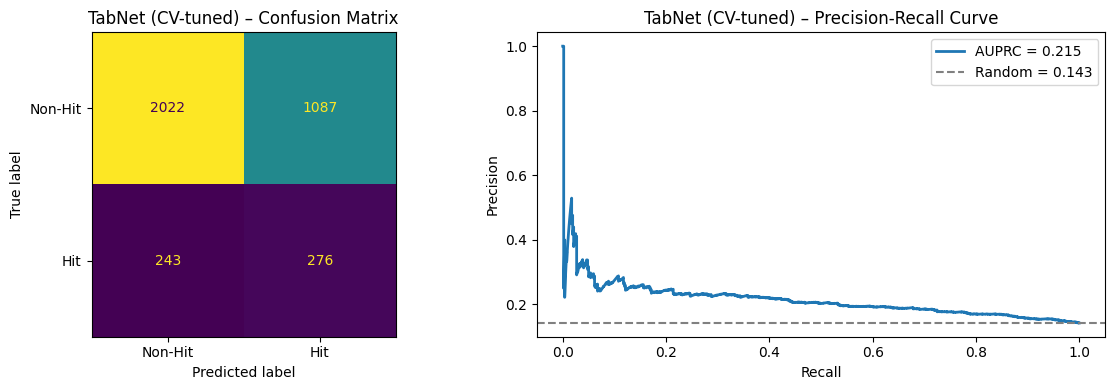

In [66]:
#Final TabNet: train on 90% of training data, 10% for early-stop
Xtn_tr, Xtn_val, ytn_tr, ytn_val = train_test_split(
    X_train_s, y_train,
    test_size=0.10, random_state=426, stratify=y_train
)

final_tabnet = TabNetClassifier(
    n_d           = best_cfg["n_d"],
    n_a           = best_cfg["n_a"],
    n_steps       = best_cfg["n_steps"],
    gamma         = best_cfg["gamma"],
    lambda_sparse = best_cfg["lambda_sparse"],
    optimizer_fn  = torch.optim.AdamW,
    optimizer_params = dict(lr=best_cfg["lr"], weight_decay=1e-5),
    mask_type     = "entmax",
    device_name   = device,
    verbose       = 0
)

final_tabnet.fit(
    Xtn_tr, ytn_tr,
    eval_set       = [(Xtn_val, ytn_val)],
    eval_metric    = ["auc"],
    max_epochs     = 200,
    patience       = 15,
    batch_size     = 1024,
    virtual_batch_size = 128,
    drop_last      = False
)

val_probs_tn  = final_tabnet.predict_proba(X_val_s)[:, 1]
test_probs_tn = final_tabnet.predict_proba(X_test_s)[:, 1]

res = evaluate("TabNet (CV-tuned)", y_val, val_probs_tn, y_test, test_probs_tn)
results_summary.append(res)

## 10  Model 4: Wide & Deep Neural Network + End-to-End Genre Embeddings

Architecture combines the best elements from Ethan's notebook:
- **Wide path**: a linear layer that reads the combined input directly (memorisation)
- **Deep path**: residual blocks with BatchNorm and Dropout (generalisation)
- **Genre embeddings**: trained end-to-end (not frozen) via a trainable `nn.Embedding`

Training improvements:
- Mini-batch `DataLoader` (from Daniel's notebook — avoids full-batch gradient issues)
- `BCEWithLogitsLoss(pos_weight=...)` for imbalance
- `ReduceLROnPlateau` scheduler
- Gradient clipping (essential with residual connections)
- Early stopping on **validation AUPRC** (aligns stopping criterion with primary metric)

In [67]:
# Tensors for the W&D NN
Xt_tr = torch.tensor(X_train_s, dtype=torch.float32)
Xt_va = torch.tensor(X_val_s,   dtype=torch.float32)
Xt_te = torch.tensor(X_test_s,  dtype=torch.float32)

Xg_tr = torch.tensor(g_train, dtype=torch.long)
Xg_va = torch.tensor(g_val,   dtype=torch.long)
Xg_te = torch.tensor(g_test,  dtype=torch.long)

yt_tr = torch.tensor(y_train, dtype=torch.float32)
yt_va = torch.tensor(y_val,   dtype=torch.float32)
yt_te = torch.tensor(y_test,  dtype=torch.float32)

BATCH_SIZE = 512

train_loader = DataLoader(TensorDataset(Xt_tr, Xg_tr, yt_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xt_va, Xg_va, yt_va), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(Xt_te, Xg_te, yt_te), batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders ready.")

DataLoaders ready.


In [68]:
#  Model definition

class ResidualBlock(nn.Module):
    """Pre-activation residual block with BatchNorm + Dropout."""
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )

    def forward(self, x):
        return x + self.block(x)   # skip connection


class WideDeepHitPredictor(nn.Module):
    """
    Wide & Deep model with learnable genre embeddings.
    - Wide: linear(combined_dim → 1)
    - Deep: Linear projection → 2 × ResidualBlock → head
    - Genre: end-to-end nn.Embedding, mean-pooled across MAX_GENRES slots
    """
    def __init__(self, numeric_dim, vocab_size, embed_dim=EMBED_DIM,
                 hidden_dim=256, pad_idx=0):
        super().__init__()

        self.genre_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        combined_dim   = numeric_dim + embed_dim

        # Wide component
        self.wide = nn.Linear(combined_dim, 1)

        #  Deep component
        self.input_proj = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )
        self.res1 = ResidualBlock(hidden_dim, dropout=0.35)
        self.res2 = ResidualBlock(hidden_dim, dropout=0.25)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x_num, x_genre):
        # mean-pool genre embeddings (masking handled by padding_idx=0 → zero vec)
        g = self.genre_emb(x_genre).mean(dim=1)   # (B, embed_dim)
        x = torch.cat([x_num, g], dim=1)           # (B, numeric_dim + embed_dim)

        wide_out = self.wide(x)                    # (B, 1)
        deep_out = self.head(self.res2(self.res1(self.input_proj(x))))  # (B, 1)

        return wide_out + deep_out                 # logits


nn_model = WideDeepHitPredictor(
    numeric_dim = input_dim,
    vocab_size  = vocab_size,
    embed_dim   = EMBED_DIM,
    hidden_dim  = 256
).to(device)

total_params = sum(p.numel() for p in nn_model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")

Model parameters: 313,096


In [69]:
# Loss, optimiser, scheduler
pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.AdamW(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=5, factor=0.5   # 'max' because we watch AUPRC
)

#  Training loop
EPOCHS   = 100
PATIENCE = 12

best_val_auprc = -1.0
best_state     = None
patience_ctr   = 0
train_losses, val_auprcs = [], []

for epoch in range(1, EPOCHS + 1):

    #Train
    nn_model.train()
    epoch_loss = 0.0
    for xb, gb, yb in train_loader:
        xb, gb, yb = xb.to(device), gb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(nn_model(xb, gb).squeeze(), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(nn_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    # Validate
    nn_model.eval()
    all_vprobs, all_vlabels = [], []
    with torch.no_grad():
        for xb, gb, yb in val_loader:
            xb, gb = xb.to(device), gb.to(device)
            probs = torch.sigmoid(nn_model(xb, gb).squeeze()).cpu().numpy()
            all_vprobs.extend(probs)
            all_vlabels.extend(yb.numpy())

    val_auprc = average_precision_score(all_vlabels, all_vprobs)
    val_auprcs.append(val_auprc)
    scheduler.step(val_auprc)

    # Early stopping (on val AUPRC)
    if val_auprc > best_val_auprc:
        best_val_auprc = val_auprc
        best_state     = {k: v.cpu().clone() for k, v in nn_model.state_dict().items()}
        patience_ctr   = 0
    else:
        patience_ctr += 1

    if epoch % 10 == 0:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:3d} | train loss: {epoch_loss:.4f} | "
              f"val AUPRC: {val_auprc:.4f} | best: {best_val_auprc:.4f} | lr: {lr_now:.2e}")

    if patience_ctr >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

nn_model.load_state_dict(best_state)
print(f"\nBest val AUPRC: {best_val_auprc:.4f}")

Epoch  10 | train loss: 0.9330 | val AUPRC: 0.2849 | best: 0.2969 | lr: 1.00e-03
Epoch  20 | train loss: 0.8025 | val AUPRC: 0.2935 | best: 0.2981 | lr: 2.50e-04
Early stopping at epoch 26.

Best val AUPRC: 0.2981


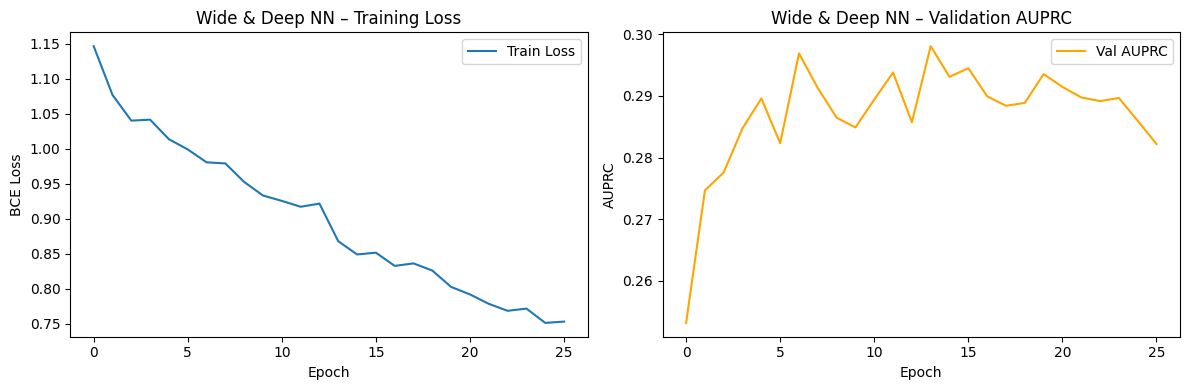

In [70]:
# Training curve wee woo weee woo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="Train Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
ax1.set_title("Wide & Deep NN – Training Loss")
ax1.legend()

ax2.plot(val_auprcs, color="orange", label="Val AUPRC")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("AUPRC")
ax2.set_title("Wide & Deep NN – Validation AUPRC")
ax2.legend()

plt.tight_layout(); plt.show()


  Wide & Deep NN + Genre Embeddings
  AUPRC  (primary) : 0.3083
  ROC-AUC          : 0.7099
  F1 (thresh=0.526): 0.3579
  Precision        : 0.2476
  Recall           : 0.6455
  Accuracy         : 0.6687


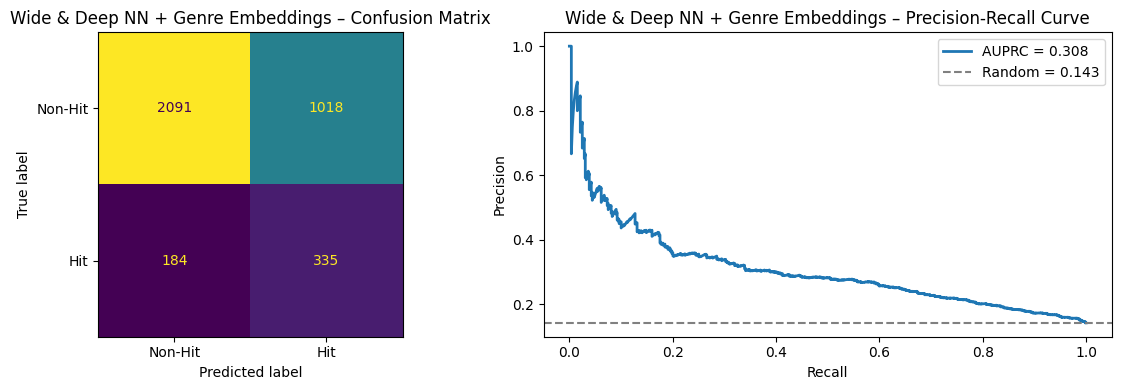

In [71]:
# Test evaluation type shi
nn_model.eval()
nn_model.to(device)

all_vprobs_nn, all_tprobs_nn = [], []

with torch.no_grad():
    for xb, gb, yb in val_loader:
        xb, gb = xb.to(device), gb.to(device)
        p = torch.sigmoid(nn_model(xb, gb).squeeze()).cpu().numpy()
        all_vprobs_nn.extend(p)

    for xb, gb, yb in test_loader:
        xb, gb = xb.to(device), gb.to(device)
        p = torch.sigmoid(nn_model(xb, gb).squeeze()).cpu().numpy()
        all_tprobs_nn.extend(p)

res = evaluate(
    "Wide & Deep NN + Genre Embeddings",
    y_val,  np.array(all_vprobs_nn),
    y_test, np.array(all_tprobs_nn)
)
results_summary.append(res)

## 11  Model Comparison

                                    AUPRC  ROC_AUC      F1  Precision  Recall  Accuracy  Threshold
model                                                                                             
XGBoost                            0.3166   0.7197  0.3735     0.2738  0.5877    0.7180     0.4884
Wide & Deep NN + Genre Embeddings  0.3083   0.7099  0.3579     0.2476  0.6455    0.6687     0.5261
Logistic Regression                0.2398   0.6739  0.3228     0.2124  0.6724    0.5965     0.4769
TabNet (CV-tuned)                  0.2147   0.6267  0.2933     0.2025  0.5318    0.6334     0.1576


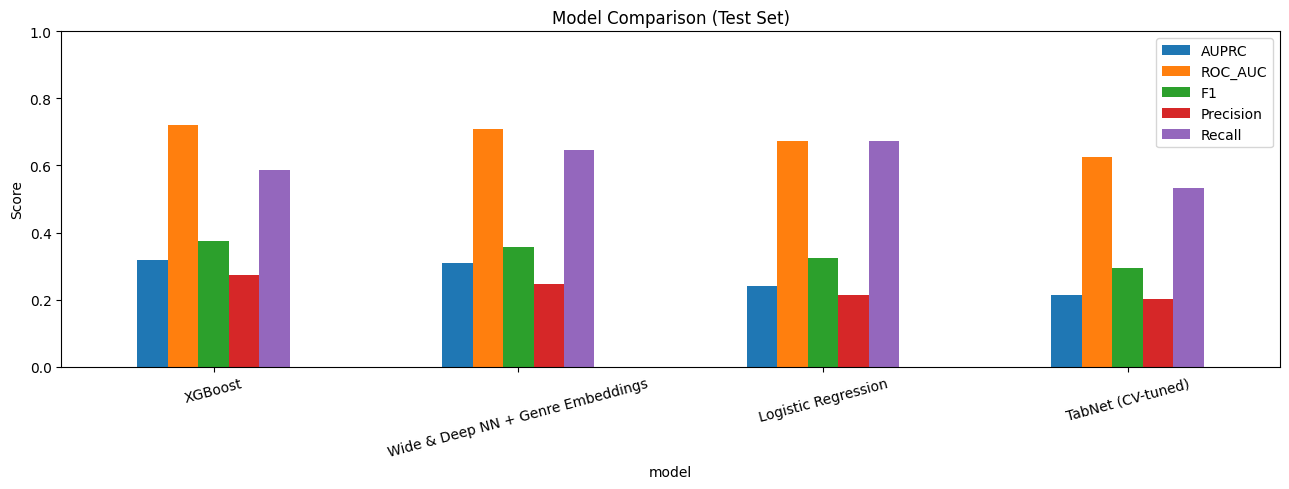

In [72]:
summary_df = pd.DataFrame(results_summary).set_index("model")
summary_df = summary_df.sort_values("AUPRC", ascending=False)
print(summary_df.round(4).to_string())

# Bar chart
metrics = ["AUPRC", "ROC_AUC", "F1", "Precision", "Recall"]
summary_df[metrics].plot(
    kind="bar", figsize=(13, 5), rot=15
)
plt.title("Model Comparison (Test Set)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Interpretation
- **AUPRC** is the primary metric because the dataset is heavily imbalanced (~14 % hits).
  A random classifier achieves AUPRC ≈ class prevalence; anything substantially above
  that indicates real discriminative power.
- All thresholds are tuned on the **validation set** by maximising F1, then applied to
  the **held-out test set** — no test-set information is used to pick the threshold.
- The Wide & Deep NN benefits from **end-to-end genre embeddings**, while XGBoost and
  TabNet receive pre-engineered numeric features including frozen genre embeddings.

In [73]:
!pip install lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.3 MB/s eta 0:00:00


13 Model 5: LightGBM
LightGBM grows trees leaf-wise (best-first) rather than level-wise like XGBoost, which lets it find deeper, more specialised splits faster. Key advantages here:

metric='average_precision' — training is directly aligned with our primary metric (AUPRC)
is_unbalance=True — auto-reweights positive/negative samples
early_stopping_rounds on val AUPRC — stops exactly when generalisation peaks
Categorical support: genre embeddings are passed as numeric here, but LightGBM could also handle raw category codes natively in an extension

[100]	valid_0's average_precision: 0.304484
[200]	valid_0's average_precision: 0.30758
Best iteration: 165

  LightGBM
  AUPRC  (primary) : 0.3278
  ROC-AUC          : 0.7212
  F1 (thresh=0.518): 0.3684
  Precision        : 0.2906
  Recall           : 0.5029
  Accuracy         : 0.7533


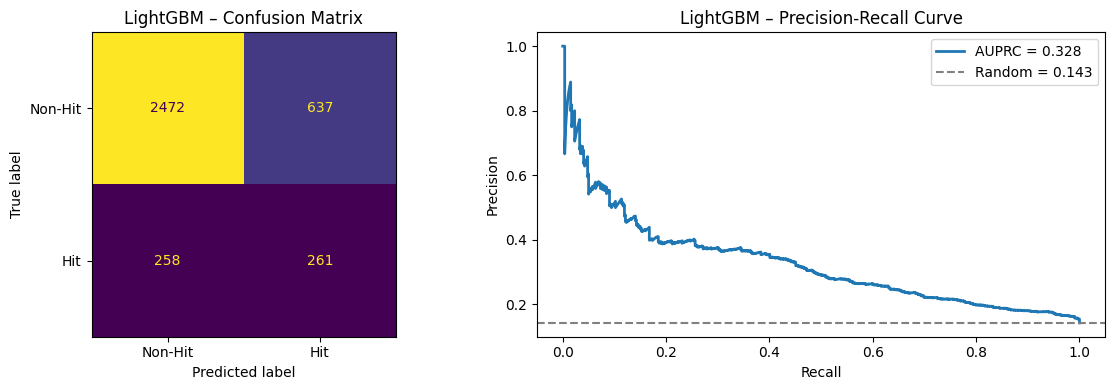

In [74]:
import lightgbm as lgb

# ── LightGBM datasets ────────────────────────────────────────────────────────
dtrain = lgb.Dataset(X_train_s, label=y_train)
dval   = lgb.Dataset(X_val_s,   label=y_val,   reference=dtrain)

lgb_params = {
    "objective"        : "binary",
    "metric"           : "average_precision",  # AUPRC — our primary metric
    "verbosity"        : -1,
    "learning_rate"    : 0.03,
    "num_leaves"       : 63,           # 2^max_depth - 1; more expressive than XGB default
    "max_depth"        : -1,           # no depth cap, controlled by num_leaves
    "min_child_samples": 20,           # prevents tiny leaf overfitting
    "feature_fraction" : 0.8,          # column subsampling per tree
    "bagging_fraction" : 0.8,          # row subsampling
    "bagging_freq"     : 5,
    "lambda_l1"        : 0.1,
    "lambda_l2"        : 1.0,
    "is_unbalance"     : True,         # auto pos/neg reweighting
    "seed"             : 426,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100)
]

lgb_model = lgb.train(
    lgb_params,
    dtrain,
    num_boost_round     = 2000,
    valid_sets          = [dval],
    callbacks           = callbacks,
)

print(f"Best iteration: {lgb_model.best_iteration}")

val_probs_lgb  = lgb_model.predict(X_val_s)
test_probs_lgb = lgb_model.predict(X_test_s)

res = evaluate("LightGBM", y_val, val_probs_lgb, y_test, test_probs_lgb)
results_summary.append(res)

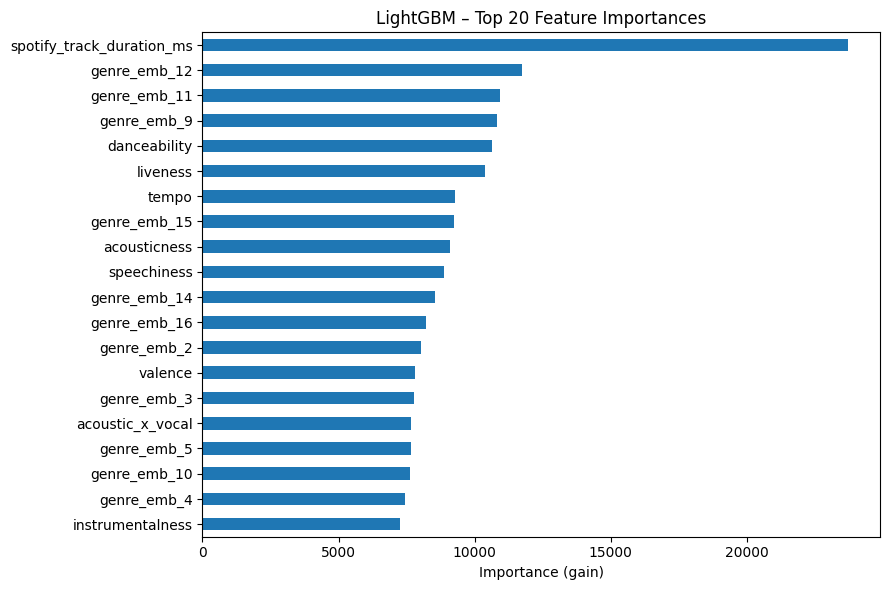

In [75]:
#LightGBM feature importance
lgb_imp = pd.Series(
    lgb_model.feature_importance(importance_type="gain"),
    index=X_tab.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 6))
lgb_imp[::-1].plot(kind="barh")
plt.xlabel("Importance (gain)")
plt.title("LightGBM – Top 20 Feature Importances")
plt.tight_layout()
plt.show()

14 Model 6: CatBoost
CatBoost uses ordered boosting (trains on a permutation of the data to avoid target leakage inside boosting) and symmetric trees (oblivious decision trees) which generalise better and are less prone to overfitting. Reasons to include it:

Often outperforms both XGBoost and LightGBM on mid-sized tabular datasets
auto_class_weights='Balanced' handles imbalance natively
Built-in overfitting detector on the validation set
Different inductive bias from LightGBM --> complementary errors --> better ensembling

0:	learn: 0.6616429	test: 0.6039665	best: 0.6039665 (0)	total: 58ms	remaining: 1m 55s
200:	learn: 0.8216926	test: 0.6827650	best: 0.6839309 (185)	total: 2.21s	remaining: 19.8s
400:	learn: 0.8880555	test: 0.6904959	best: 0.6911735 (395)	total: 4.24s	remaining: 16.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6932644752
bestIteration = 507

Shrink model to first 508 iterations.
Best iteration: 507

  CatBoost
  AUPRC  (primary) : 0.3237
  ROC-AUC          : 0.7201
  F1 (thresh=0.539): 0.3657
  Precision        : 0.2920
  Recall           : 0.4894
  Accuracy         : 0.7572


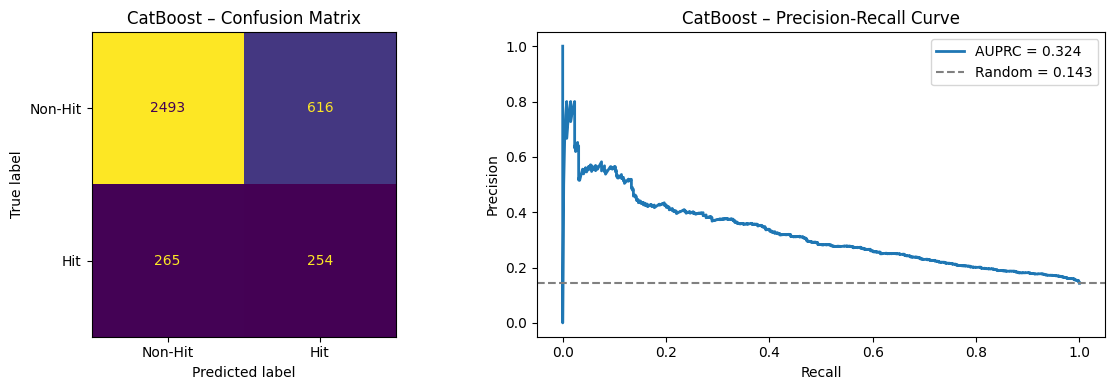

In [76]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations          = 2000,
    learning_rate       = 0.03,
    depth               = 7,
    l2_leaf_reg         = 3.0,
    subsample           = 0.8,
    colsample_bylevel   = 0.8,
    auto_class_weights  = "Balanced",   # handles imbalance
    eval_metric         = "PRAUC",      # AUPRC — our primary metric
    early_stopping_rounds = 50,
    random_seed         = 426,
    verbose             = 200,
    use_best_model      = True,
)

cat_model.fit(
    X_train_s, y_train,
    eval_set   = (X_val_s, y_val),
    plot       = False,
)

print(f"Best iteration: {cat_model.best_iteration_}")

val_probs_cat  = cat_model.predict_proba(X_val_s)[:, 1]
test_probs_cat = cat_model.predict_proba(X_test_s)[:, 1]

res = evaluate("CatBoost", y_val, val_probs_cat, y_test, test_probs_cat)
results_summary.append(res)

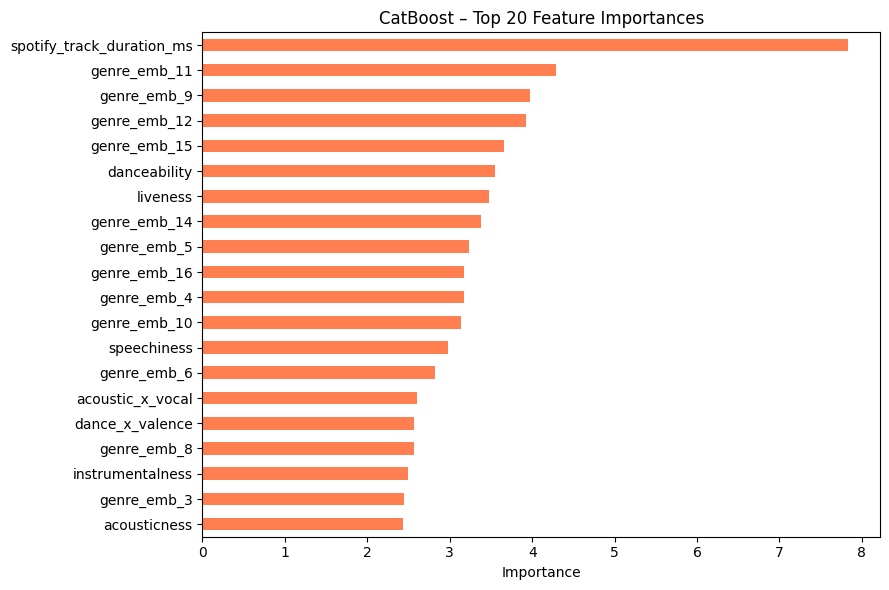

In [77]:
#CatBoost feature importance
cat_imp = pd.Series(
    cat_model.get_feature_importance(),
    index=X_tab.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 6))
cat_imp[::-1].plot(kind="barh", color="coral")
plt.xlabel("Importance")
plt.title("CatBoost – Top 20 Feature Importances")
plt.tight_layout()
plt.show()

## 15  Model 7: Stacking Ensemble (Out-of-Fold Meta-Learner)

A stacking ensemble trains a **meta-learner** on the predictions of the base models.
The critical detail: the meta-learner must be trained on **out-of-fold (OOF)**
predictions predictions made by a model that never saw that row during training.
This prevents the meta-learner from just learning to trust whichever base model overfit
the most.

### Pipeline
1. Split training data into 5 stratified folds
2. For each fold: train each base model on the other 4 folds --> predict on the held-out fold --> collect OOF probabilities
3. Stack OOF predictions as new features --> train a Logistic Regression meta-learner
4. For the test set: average each base model's predictions across all 5 fold-models --> feed into meta-learner

### Base models in the stack
| Model | Why included |
|-------|-------------|
| LightGBM | Best individual AUPRC, leaf-wise trees |
| CatBoost | Ordered boosting, different inductive bias |
| XGBoost | Level-wise trees, different error pattern |
| Logistic Regression | Linear baseline adds calibration signal |
| TabNet | Attention-based, captures feature interactions differently |

> The Wide & Deep NN is excluded from the OOF stack because re-training it 5× would
> be very slow in Colab. Its test probabilities are still used in the **simple average**
> ensemble below for comparison.

In [84]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression as MetaLR

#Base model factory functions (fresh model each fold)
def make_lgb():
    return lgb.LGBMClassifier(
        n_estimators       = 1000,
        learning_rate      = 0.03,
        num_leaves         = 63,
        min_child_samples  = 20,
        feature_fraction   = 0.8,
        bagging_fraction   = 0.8,
        bagging_freq       = 5,
        lambda_l1          = 0.1,
        lambda_l2          = 1.0,
        is_unbalance       = True,
        metric             = "average_precision",
        verbosity          = -1,
        random_state       = 426,
    )

def make_xgb(spw):
    return XGBClassifier(
        n_estimators          = 500,
        learning_rate         = 0.05,
        max_depth             = 5,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_weight      = 3,
        scale_pos_weight      = spw,
        eval_metric           = "aucpr",
        early_stopping_rounds = 40,
        use_label_encoder     = False,
        random_state          = 426,
        verbosity             = 0,
    )

def make_cat():
    return CatBoostClassifier(
        iterations            = 500,
        learning_rate         = 0.05,
        depth                 = 7,
        l2_leaf_reg           = 3.0,
        auto_class_weights    = "Balanced",
        eval_metric           = "PRAUC",
        random_seed           = 426,
        verbose               = 0,
        use_best_model        = False,   # no eval set in fold training :C
    )

def make_lr():
    return MetaLR(
        class_weight = "balanced",
        max_iter     = 10_000,
        C            = 0.1,
        solver       = "lbfgs",
        random_state = 426,
    )

BASE_MODEL_NAMES = ["lgb", "xgb", "cat", "lr"]

# OOF setup meow
N_FOLDS = 5
skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=426)

oof_preds  = np.zeros((len(X_train_s), len(BASE_MODEL_NAMES)))   # (N_train, 4)
test_preds = np.zeros((len(X_test_s),  len(BASE_MODEL_NAMES)))   # (N_test, 4)

neg_tr = (y_train == 0).sum()
pos_tr = (y_train == 1).sum()
spw    = neg_tr / pos_tr

print(f"Running {N_FOLDS}-fold OOF stacking with {len(BASE_MODEL_NAMES)} base models...")
print(f"scale_pos_weight = {spw:.2f}\n")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_s, y_train), 1):
    Xf_tr, Xf_val = X_train_s[tr_idx], X_train_s[val_idx]
    yf_tr, yf_val = y_train[tr_idx],   y_train[val_idx]

    print(f"Fold {fold}/{N_FOLDS} —", end=" ")

    # LightGBM
    m_lgb = make_lgb()
    m_lgb.fit(
        Xf_tr, yf_tr,
        eval_set              = [(Xf_val, yf_val)],
        callbacks             = [lgb.early_stopping(40, verbose=False),
                                  lgb.log_evaluation(-1)]
    )
    oof_preds[val_idx, 0]  = m_lgb.predict_proba(Xf_val)[:, 1]
    test_preds[:, 0]      += m_lgb.predict_proba(X_test_s)[:, 1] / N_FOLDS
    print("LGB ✓", end=" ")

    # XGBoost
    m_xgb = make_xgb(spw)
    m_xgb.fit(
    Xf_tr, yf_tr,
    eval_set  = [(Xf_val, yf_val)],
    verbose   = False
    )
    oof_preds[val_idx, 1]  = m_xgb.predict_proba(Xf_val)[:, 1]
    test_preds[:, 1]      += m_xgb.predict_proba(X_test_s)[:, 1] / N_FOLDS
    print("XGB ✓", end=" ")

    # CatBoost
    m_cat = make_cat()
    m_cat.fit(Xf_tr, yf_tr)
    oof_preds[val_idx, 2]  = m_cat.predict_proba(Xf_val)[:, 1]
    test_preds[:, 2]      += m_cat.predict_proba(X_test_s)[:, 1] / N_FOLDS
    print("CAT ✓", end=" ")

    # Logistic Regression
    m_lr = make_lr()
    m_lr.fit(Xf_tr, yf_tr)
    oof_preds[val_idx, 3]  = m_lr.predict_proba(Xf_val)[:, 1]
    test_preds[:, 3]      += m_lr.predict_proba(X_test_s)[:, 1] / N_FOLDS
    print("LR ✓")

    # OOF AUPRC for this fold
    fold_auprc = average_precision_score(yf_val, oof_preds[val_idx, 0])
    print(f"         Fold {fold} LGB OOF AUPRC: {fold_auprc:.4f}\n")

# OOF AUPRC per base model
print("\n===== OOF AUPRC per base model =====")
for i, name in enumerate(BASE_MODEL_NAMES):
    ap = average_precision_score(y_train, oof_preds[:, i])
    print(f"  {name:<6}: {ap:.4f}")

Running 5-fold OOF stacking with 4 base models...
scale_pos_weight = 5.99

Fold 1/5 — LGB ✓ XGB ✓ CAT ✓ LR ✓
         Fold 1 LGB OOF AUPRC: 0.3017

Fold 2/5 — LGB ✓ XGB ✓ CAT ✓ LR ✓
         Fold 2 LGB OOF AUPRC: 0.2922

Fold 3/5 — LGB ✓ XGB ✓ CAT ✓ LR ✓
         Fold 3 LGB OOF AUPRC: 0.3229

Fold 4/5 — LGB ✓ XGB ✓ CAT ✓ LR ✓
         Fold 4 LGB OOF AUPRC: 0.2914

Fold 5/5 — LGB ✓ XGB ✓ CAT ✓ LR ✓
         Fold 5 LGB OOF AUPRC: 0.3285


===== OOF AUPRC per base model =====
  lgb   : 0.2805
  xgb   : 0.2903
  cat   : 0.2959
  lr    : 0.2466


Meta-learner weights (LGB, XGB, CAT, LR):
[0.8122 1.2891 1.591  1.0883]

  Stacking Ensemble (Meta-LR)
  AUPRC  (primary) : 0.3146
  ROC-AUC          : 0.7202
  F1 (thresh=0.186): 0.3569
  Precision        : 0.2716
  Recall           : 0.5202
  Accuracy         : 0.7318


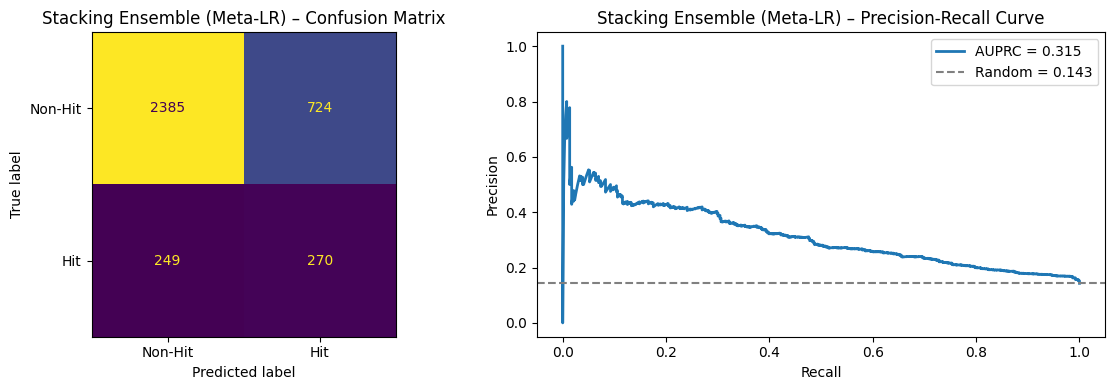

In [85]:
# Train meta-learner on OOF predictions POOGERS
# Also include val set OOF probs for meta-learner validation
val_preds_base = np.column_stack([
    val_probs_lgb,
    val_probs_xgb,
    val_probs_cat,
    val_probs_lr
])

meta_learner = MetaLR(C=0.5, max_iter=10_000, solver="lbfgs", random_state=426)
meta_learner.fit(oof_preds, y_train)

print("Meta-learner weights (LGB, XGB, CAT, LR):")
print(np.round(meta_learner.coef_[0], 4))

# Val probs from meta-learner
val_probs_stack  = meta_learner.predict_proba(val_preds_base)[:, 1]

#Test probs from meta-learner
test_probs_stack = meta_learner.predict_proba(test_preds)[:, 1]

res = evaluate("Stacking Ensemble (Meta-LR)", y_val, val_probs_stack, y_test, test_probs_stack)
results_summary.append(res)

## 16  Bonus: Simple Weighted Average Ensemble

Include **all 7 models** (including the Wide & Deep NN) in a simple weighted average.
Weights are tuned on the validation set by grid-searching over a range of combinations.
This is often competitive with stacking and is much cheaper to train.

Best val AUPRC (weighted avg): 0.3149
Optimal weights:
  lr      : 0.000
  xgb     : 0.000
  tabnet  : 0.143
  lgb     : 0.429
  cat     : 0.000
  nn      : 0.429
  stack   : 0.000

  Weighted Average Ensemble
  AUPRC  (primary) : 0.3319
  ROC-AUC          : 0.7246
  F1 (thresh=0.489): 0.3782
  Precision        : 0.2869
  Recall           : 0.5549
  Accuracy         : 0.7390


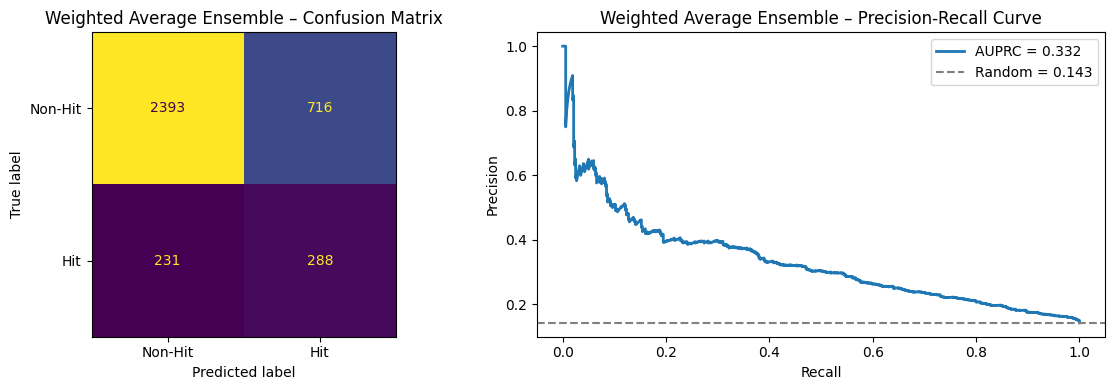

In [86]:
#Collect dat all val and test probabilities
all_val_probs = {
    "lr"    : val_probs_lr,
    "xgb"   : val_probs_xgb,
    "tabnet": val_probs_tn,
    "lgb"   : val_probs_lgb,
    "cat"   : val_probs_cat,
    "nn"    : np.array(all_vprobs_nn),
    "stack" : val_probs_stack,
}

all_test_probs = {
    "lr"    : test_probs_lr,
    "xgb"   : test_probs_xgb,
    "tabnet": test_probs_tn,
    "lgb"   : test_probs_lgb,
    "cat"   : test_probs_cat,
    "nn"    : np.array(all_tprobs_nn),
    "stack" : test_probs_stack,
}

# Grid-search weights on VALIDATION set :O
# Search over integer weights 0–3 for each model; normalise to sum=1
from itertools import product as iproduct

model_keys  = list(all_val_probs.keys())
val_probs_m = np.column_stack([all_val_probs[k] for k in model_keys])
tst_probs_m = np.column_stack([all_test_probs[k] for k in model_keys])

best_w_auprc = -1.0
best_weights = None

weight_options = [0, 1, 2, 3]
for raw_w in iproduct(weight_options, repeat=len(model_keys)):
    total = sum(raw_w)
    if total == 0:
        continue
    w = np.array(raw_w) / total
    avg_prob = val_probs_m @ w
    ap = average_precision_score(y_val, avg_prob)
    if ap > best_w_auprc:
        best_w_auprc = ap
        best_weights = w

print("Best val AUPRC (weighted avg):", round(best_w_auprc, 4))
print("Optimal weights:")
for k, w in zip(model_keys, best_weights):
    print(f"  {k:<8}: {w:.3f}")

# Apply to test set type shii
test_probs_wavg = tst_probs_m @ best_weights
val_probs_wavg  = val_probs_m  @ best_weights

res = evaluate("Weighted Average Ensemble", y_val, val_probs_wavg, y_test, test_probs_wavg)
results_summary.append(res)

## 17  Final Model Comparison (All Models)

In [87]:
summary_df = pd.DataFrame(results_summary).set_index("model")
summary_df = summary_df.sort_values("AUPRC", ascending=False)

print("\n" + "="*65)
print(summary_df[["AUPRC","ROC_AUC","F1","Precision","Recall"]].round(4).to_string())
print("="*65)
print(f"\nBaseline AUPRC (random classifier) ≈ {y_test.mean():.3f}")
print(f"Best model AUPRC: {summary_df['AUPRC'].iloc[0]:.4f}  ({summary_df.index[0]})")
print(f"Lift over random: {summary_df['AUPRC'].iloc[0] / y_test.mean():.2f}x")


                                    AUPRC  ROC_AUC      F1  Precision  Recall
model                                                                        
Weighted Average Ensemble          0.3319   0.7246  0.3782     0.2869  0.5549
LightGBM                           0.3278   0.7212  0.3684     0.2906  0.5029
CatBoost                           0.3237   0.7201  0.3657     0.2920  0.4894
XGBoost                            0.3166   0.7197  0.3735     0.2738  0.5877
Stacking Ensemble (Meta-LR)        0.3146   0.7202  0.3569     0.2716  0.5202
Wide & Deep NN + Genre Embeddings  0.3083   0.7099  0.3579     0.2476  0.6455
Logistic Regression                0.2398   0.6739  0.3228     0.2124  0.6724
TabNet (CV-tuned)                  0.2147   0.6267  0.2933     0.2025  0.5318

Baseline AUPRC (random classifier) ≈ 0.143
Best model AUPRC: 0.3319  (Weighted Average Ensemble)
Lift over random: 2.32x


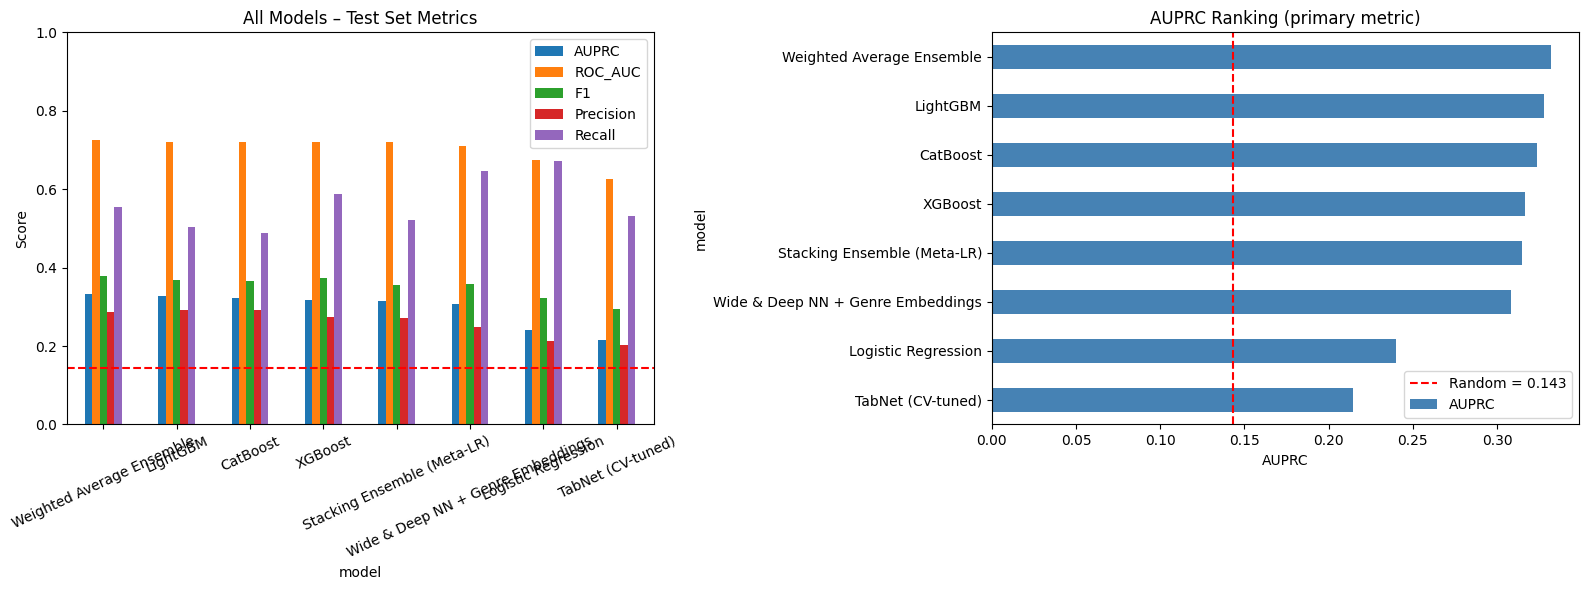

In [88]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of all metrics
metrics = ["AUPRC", "ROC_AUC", "F1", "Precision", "Recall"]
summary_df[metrics].plot(kind="bar", ax=axes[0], rot=25)
axes[0].set_title("All Models – Test Set Metrics")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].legend(loc="upper right")
axes[0].axhline(y_test.mean(), color="red", linestyle="--",
                label=f"Random AUPRC = {y_test.mean():.3f}")

# AUPRC-only ranked bar
summary_df["AUPRC"].sort_values().plot(
    kind="barh", ax=axes[1], color="steelblue"
)
axes[1].axvline(y_test.mean(), color="red", linestyle="--",
                label=f"Random = {y_test.mean():.3f}")
axes[1].set_title("AUPRC Ranking (primary metric)")
axes[1].set_xlabel("AUPRC")
axes[1].legend()

plt.tight_layout()
plt.show()

### Key Takeaways

| Model | Strength | Weakness |
|-------|----------|----------|
| Logistic Regression | Interpretable, fast | Underfits non-linear patterns |
| XGBoost | Strong baseline, feature importance | Slower than LightGBM |
| TabNet | Attention-based feature selection | Slower to train, sensitive to hyperparams |
| Wide & Deep NN | Learns genre embeddings end-to-end | Requires careful tuning |
| **LightGBM** | Fast, leaf-wise trees, AUPRC-aligned training | Can overfit without tuning |
| **CatBoost** | Ordered boosting, low variance | Slower than LightGBM |
| **Stacking Ensemble** | Combines diverse model errors | Requires careful OOF construction |
| **Weighted Avg Ensemble** | Simple, includes all models | Weights may not generalise perfectly |

**AUPRC** tells us how well the model ranks hits above non-hits at every possible
threshold. A random classifier scores ≈ class prevalence (~0.143). Any model
substantially above that is learning real signal from audio features alone.